In [47]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [48]:
np.random.seed(42)  # reproducibility for sampling
pd.set_option('display.width', 120)
df = pd.read_csv('data.csv')
print("Shape:", df.shape)
df.head()

Shape: (48, 13)


,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Top Team Scorer,Goalkeeper,Notes
0,1,es Spain,8,7,1,0,14,1,13,22,Mikel Oyarzabal - 5,Unai Simón,NaN
1,2,ar Argentina,8,7,0,1,19,8,11,21,Lionel Messi - 8,Emiliano Martínez,NaN
2,3,eng England,8,6,1,1,20,12,8,19,Jude Bellingham - 7,Jordan Pickford,NaN
3,4,fr France,8,6,0,2,20,10,10,18,Kylian Mbappé - 10,Mike Maignan,NaN
4,QF,no Norway,6,4,0,2,13,11,2,12,Erling Haaland - 7,Ørjan Nyland,NaN


In [49]:
stage_order = {'GR':0, 'R32':1, 'R16':2, 'QF':3, '4':4, '3':5, '2':6, '1':7}
stage_label = {0:'Group Stage', 1:'Round of 32', 2:'Round of 16', 3:'Quarterfinal',
               4:'4th Place', 5:'3rd Place', 6:'Runner-up', 7:'Champion'}

df['Stage_Code']    = df['Rk'].astype(str).map(stage_order)
df['Stage_Reached'] = df['Stage_Code'].map(stage_label)

# Binary progression flag
df['Progressed'] = np.where(df['Rk'].astype(str) == 'GR',
                             'Eliminated in Group Stage', 'Progressed to Knockouts')

# Defensive efficiency = goals conceded per match played
df['Def_Efficiency'] = df['GA'] / df['MP']

print("Missing values in key columns:")
print(df[['MP','GA','Progressed']].isna().sum())
print()
print("Group sizes:")
print(df['Progressed'].value_counts())
df[['Squad','Rk','Stage_Reached','Progressed','MP','GA','Def_Efficiency']].head(10)

Missing values in key columns:
MP            0
GA            0
Progressed    0
dtype: int64

Group sizes:
Progressed
Progressed to Knockouts      32
Eliminated in Group Stage    16
Name: count, dtype: int64


,Squad,Rk,Stage_Reached,Progressed,MP,GA,Def_Efficiency
0,es Spain,1,Champion,Progressed to Knockouts,8,1,0.125000
1,ar Argentina,2,Runner-up,Progressed to Knockouts,8,8,1.000000
2,eng England,3,3rd Place,Progressed to Knockouts,8,12,1.500000
3,fr France,4,4th Place,Progressed to Knockouts,8,10,1.250000
4,no Norway,QF,Quarterfinal,Progressed to Knockouts,6,11,1.833333
5,be Belgium,QF,Quarterfinal,Progressed to Knockouts,6,7,1.166667
6,ma Morocco,QF,Quarterfinal,Progressed to Knockouts,6,6,1.000000
7,ch Switzerland,QF,Quarterfinal,Progressed to Knockouts,6,6,1.000000
8,mx Mexico,R16,Round of 16,Progressed to Knockouts,5,3,0.600000
9,co Colombia,R16,Round of 16,Progressed to Knockouts,5,1,0.200000


In [50]:
population = df.copy()
N = len(population)
print("Population size (N):", N)

n = 30
sample = population.sample(n=n, random_state=42).reset_index(drop=True)
print("Sample size (n):", n)
print()
print("Sample group composition:")
print(sample['Progressed'].value_counts())

Population size (N): 48
Sample size (n): 30

Sample group composition:
Progressed
Progressed to Knockouts      21
Eliminated in Group Stage     9
Name: count, dtype: int64


In [51]:
print("Overall Defensive Efficiency (GA/MP) — sample, n=30")
print(sample['Def_Efficiency'].describe())
print()

desc_by_group = sample.groupby('Progressed')['Def_Efficiency'].agg(['count','mean','median','std','min','max'])
print("By group:")
desc_by_group

Overall Defensive Efficiency (GA/MP) — sample, n=30
count    30.000000
mean      1.661944
std       0.985400
min       0.125000
25%       1.000000
50%       1.250000
75%       2.250000
max       4.000000
Name: Def_Efficiency, dtype: float64

By group:


,count,mean,median,std,min,max
Progressed,,,,,,
Eliminated in Group Stage,9,2.481481,2.666667,1.167989,1.000,4.0
Progressed to Knockouts,21,1.310714,1.250000,0.656142,0.125,2.5


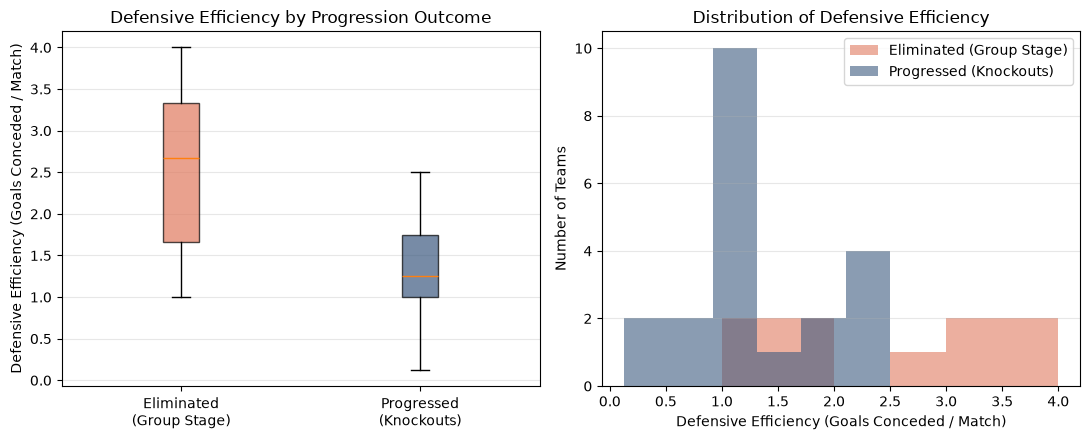

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

groups = ['Eliminated in Group Stage', 'Progressed to Knockouts']
data = [sample.loc[sample['Progressed']==g, 'Def_Efficiency'] for g in groups]
bp = axes[0].boxplot(data, tick_labels=['Eliminated\n(Group Stage)', 'Progressed\n(Knockouts)'],
                      patch_artist=True)
for patch, c in zip(bp['boxes'], ['#e07a5f', '#3d5a80']):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[0].set_ylabel('Defensive Efficiency (Goals Conceded / Match)')
axes[0].set_title('Defensive Efficiency by Progression Outcome')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(sample.loc[sample['Progressed']=='Eliminated in Group Stage','Def_Efficiency'],
             bins=6, alpha=0.6, label='Eliminated (Group Stage)', color='#e07a5f')
axes[1].hist(sample.loc[sample['Progressed']=='Progressed to Knockouts','Def_Efficiency'],
             bins=6, alpha=0.6, label='Progressed (Knockouts)', color='#3d5a80')
axes[1].set_xlabel('Defensive Efficiency (Goals Conceded / Match)')
axes[1].set_ylabel('Number of Teams')
axes[1].set_title('Distribution of Defensive Efficiency')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
def ci_mean(data, conf=0.95):
    data = np.asarray(data)
    n = len(data)
    m = data.mean()
    se = data.std(ddof=1) / np.sqrt(n)
    tcrit = stats.t.ppf((1 + conf) / 2, df=n - 1)
    return m, m - tcrit*se, m + tcrit*se

m_all, lo_all, hi_all = ci_mean(sample['Def_Efficiency'])
print(f"Whole sample (n=30): mean = {m_all:.3f}, 95% CI = ({lo_all:.3f}, {hi_all:.3f})")

prog = sample.loc[sample['Progressed'] == 'Progressed to Knockouts', 'Def_Efficiency']
elim = sample.loc[sample['Progressed'] == 'Eliminated in Group Stage', 'Def_Efficiency']

m_p, lo_p, hi_p = ci_mean(prog)
m_e, lo_e, hi_e = ci_mean(elim)
print(f"Progressed teams (n={len(prog)}): mean = {m_p:.3f}, 95% CI = ({lo_p:.3f}, {hi_p:.3f})")
print(f"Eliminated teams (n={len(elim)}): mean = {m_e:.3f}, 95% CI = ({lo_e:.3f}, {hi_e:.3f})")

Whole sample (n=30): mean = 1.662, 95% CI = (1.294, 2.030)
Progressed teams (n=21): mean = 1.311, 95% CI = (1.012, 1.609)
Eliminated teams (n=9): mean = 2.481, 95% CI = (1.584, 3.379)


In [54]:
levene_stat, levene_p = stats.levene(prog, elim)
print(f"Levene's test: stat = {levene_stat:.3f}, p = {levene_p:.4f}")

equal_var = levene_p > 0.05
t_stat, p_two_tailed = stats.ttest_ind(elim, prog, equal_var=equal_var)
test_name = "Student's t-test (equal variances)" if equal_var else "Welch's t-test (unequal variances)"

p_one_tailed = p_two_tailed/2 if t_stat > 0 else 1 - p_two_tailed/2

print(f"Test used: {test_name}")
print(f"t-statistic = {t_stat:.3f}")
print(f"one-tailed p-value = {p_one_tailed:.5f}")

alpha = 0.05
if p_one_tailed < alpha:
    print(f"\nDecision: Reject H0 (p = {p_one_tailed:.5f} < {alpha}).")
    print("Teams eliminated in the group stage concede significantly more goals per match")
    print("than teams that progressed to the knockout rounds.")
else:
    print(f"\nDecision: Fail to reject H0 (p = {p_one_tailed:.5f} >= {alpha}).")

pooled_std = np.sqrt(((len(elim)-1)*elim.std(ddof=1)**2 + (len(prog)-1)*prog.std(ddof=1)**2) /
                      (len(elim)+len(prog)-2))
cohens_d = (elim.mean() - prog.mean()) / pooled_std
print(f"\nEffect size (Cohen's d) = {cohens_d:.3f}  (>0.8 = large effect)")

Levene's test: stat = 7.854, p = 0.0091
Test used: Welch's t-test (unequal variances)
t-statistic = 2.822
one-tailed p-value = 0.00885

Decision: Reject H0 (p = 0.00885 < 0.05).
Teams eliminated in the group stage concede significantly more goals per match
than teams that progressed to the knockout rounds.

Effect size (Cohen's d) = 1.402  (>0.8 = large effect)


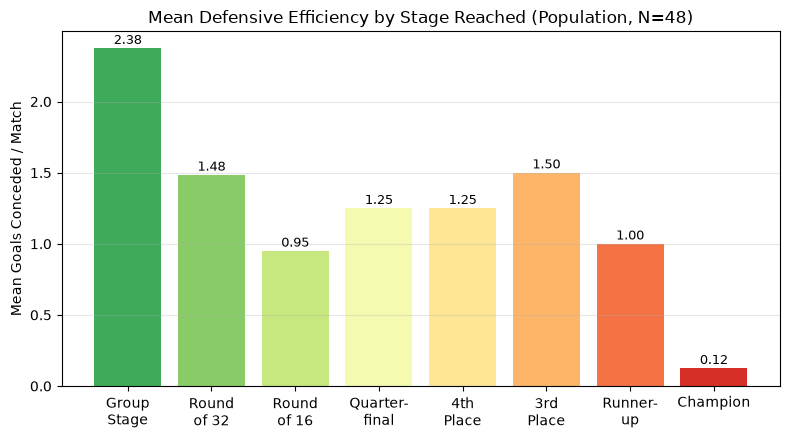

In [ ]:
# GRAPHS (population, N=48)
stage_order = {'GR':0, 'R32':1, 'R16':2, 'QF':3, '4':4, '3':5, '2':6, '1':7}
stage_label = {0:'Group\nStage', 1:'Round\nof 32', 2:'Round\nof 16', 3:'Quarter-\nfinal',
               4:'4th\nPlace', 5:'3rd\nPlace', 6:'Runner-\nup', 7:'Champion'}
df['Stage_Code']    = df['Rk'].astype(str).map(stage_order)
df['Stage_Reached'] = df['Stage_Code'].map(stage_label)
df['Off_Efficiency'] = df['GF'] / df['MP']
 
order_codes = sorted(df['Stage_Code'].unique())
labels = [stage_label[c] for c in order_codes]
 
# --- Graph 1: Bar chart - mean defensive efficiency by stage ---
means = df.groupby('Stage_Code')['Def_Efficiency'].mean().reindex(order_codes)
fig1, ax1 = plt.subplots(figsize=(8,4.5))
bars = ax1.bar(labels, means.values, color=plt.cm.RdYlGn_r(np.linspace(0.15,0.9,len(labels))))
ax1.set_ylabel('Mean Goals Conceded / Match')
ax1.set_title('Mean Defensive Efficiency by Stage Reached (Population, N=48)')
ax1.grid(axis='y', alpha=0.3)
for b, v in zip(bars, means.values):
    ax1.text(b.get_x()+b.get_width()/2, v+0.03, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()
 


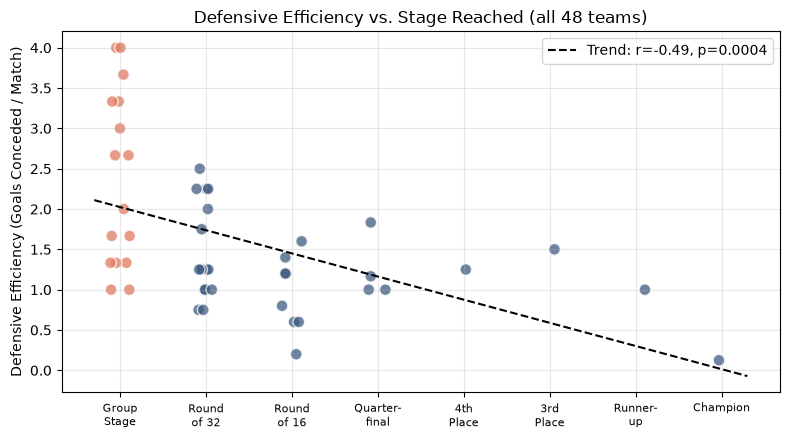

Pearson r (Stage_Code vs Def_Efficiency) = -0.489, p = 0.00042


In [ ]:
#  Scatter of defensive efficiency vs stage reached, with trend line 
fig2, ax2 = plt.subplots(figsize=(8,4.5))
jitter = np.random.uniform(-0.12,0.12,len(df))
colors = np.where(df['Progressed']=='Progressed to Knockouts', '#3d5a80', '#e07a5f')
ax2.scatter(df['Stage_Code']+jitter, df['Def_Efficiency'], c=colors, alpha=0.75, edgecolor='white', s=70)
 
slope, intercept, r, p, se = stats.linregress(df['Stage_Code'], df['Def_Efficiency'])
xline = np.linspace(-0.3, 7.3, 50)
ax2.plot(xline, slope*xline+intercept, color='black', linestyle='--', linewidth=1.5,
         label=f'Trend: r={r:.2f}, p={p:.4f}')
ax2.set_xticks(order_codes)
ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylabel('Defensive Efficiency (Goals Conceded / Match)')
ax2.set_title('Defensive Efficiency vs. Stage Reached (all 48 teams)')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Pearson r (Stage_Code vs Def_Efficiency) = {r:.3f}, p = {p:.5f}")
 


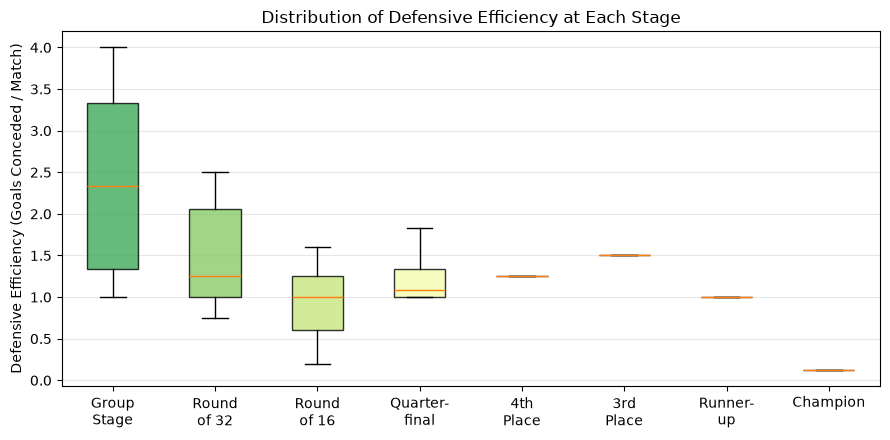

In [ ]:
# Boxplot of defensive efficiency at every stage
fig3, ax3 = plt.subplots(figsize=(9,4.5))
box_data = [df.loc[df['Stage_Code']==c, 'Def_Efficiency'] for c in order_codes]
bp = ax3.boxplot(box_data, tick_labels=labels, patch_artist=True)
cmap = plt.cm.RdYlGn_r(np.linspace(0.15,0.9,len(labels)))
for patch, c in zip(bp['boxes'], cmap):
    patch.set_facecolor(c); patch.set_alpha(0.8)
ax3.set_ylabel('Defensive Efficiency (Goals Conceded / Match)')
ax3.set_title('Distribution of Defensive Efficiency at Each Stage')
ax3.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
 
